In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve


In [2]:
with open('control_feedback_photodiode.bin','rb') as file:
    data = np.fromfile(file,dtype='int16').astype('float32')

# Sample rate os 10k and beam is moving over a 10 mm distance
x_feedback = data[1::3]
x_control = data[0::3]
photodiode = data[2::3]

In [3]:
# Define a function to scale a waveform between 0 and 1
def normWaveform(data,window_size=0):
    data = data - data.min()
    data = data / data.max()
    
    if window_size>0:
        boxcar = np.ones(window_size) / window_size
        data = convolve(data, boxcar, mode='same')


    return data

### Scanner waveforms
The scanner command signal lags a little behind the control signal and it appears filtered (it's like a smoothed version of the command signal). Let's look carefully at how it appears.  

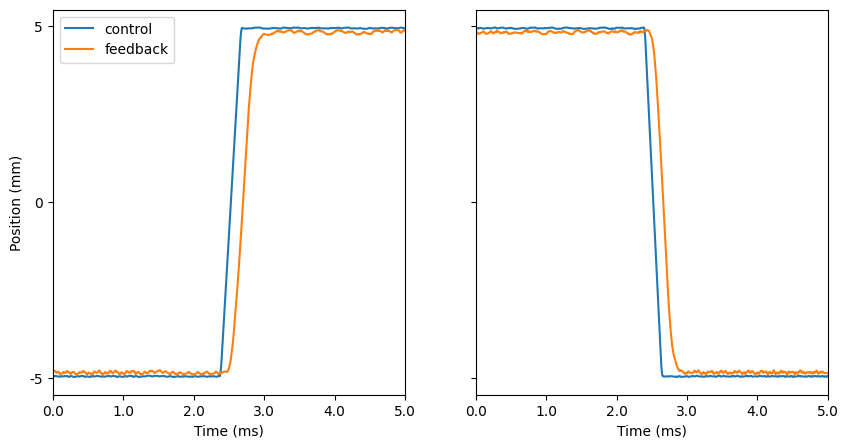

In [59]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharex=False, sharey=True)

# Let's make an x axis in ms
max_t = len(x_control)/100
x = np.linspace(0,max_t, len(x_control))

axs[1].plot(x,normWaveform(x_control,3))
axs[1].plot(x,normWaveform(x_feedback,3))


axs[0].plot(x,normWaveform(x_control,3))
axs[0].plot(x,normWaveform(x_feedback,3))

axs[0].set_xlim(290,295);

axs[0].set_yticks([0,0.5,1])
axs[0].set_yticklabels([-5,0,5]);
axs[0].set_ylabel('Position (mm)')
axs[0].legend(('control','feedback'))
axs[0].set_xlabel('Time (ms)')
axs[0].set_xticks(np.linspace(290,295,6));
axs[0].set_xticklabels(np.linspace(0,5,6))

axs[1].set_xlim(177,183);
axs[1].set_yticks([0,0.5,1])
axs[1].set_yticklabels([-5,0,5]);
axs[1].set_xlabel('Time (ms)');
axs[1].set_xticks(np.linspace(177,183,6));
axs[1].set_xticklabels(np.linspace(0,5,6));



### Beam blanking
Coordinate beam blanking with scanner motion. The orange trace is a photodiode signal so we know for sure the beam is off.

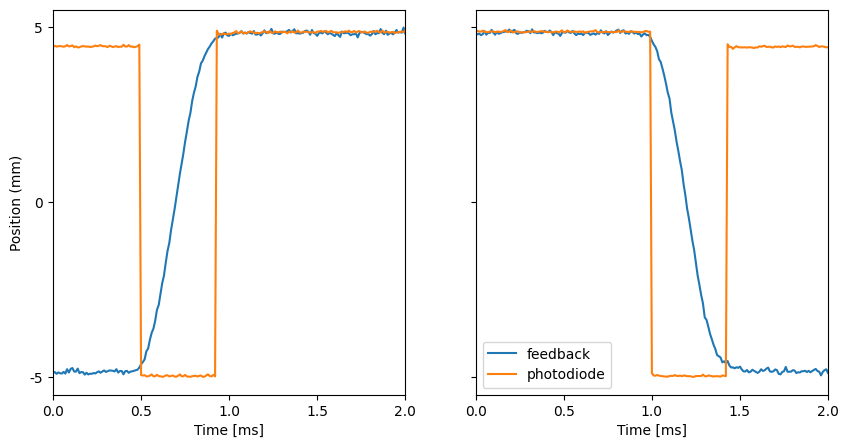

In [64]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharex=False, sharey=True)


axs[0].plot(x,normWaveform(x_feedback,0))
axs[0].plot(x,normWaveform(photodiode,0))


axs[1].plot(x,normWaveform(x_feedback,1))
axs[1].plot(x,normWaveform(photodiode))

axs[0].set_xlim(267,269);
axs[0].set_yticks([0,0.5,1])
axs[0].set_yticklabels([-5,0,5]);
axs[0].set_ylabel('Position (mm)')
axs[0].set_xticks(np.linspace(267,269,5));
axs[0].set_xticklabels(np.linspace(0,2,5));
axs[0].set_xlabel('Time [ms]')

axs[1].set_xlim(304,306);
axs[1].set_yticks([0,0.5,1])
axs[1].set_yticklabels([-5,0,5]);
axs[1].legend(('feedback','photodiode'))
axs[1].set_xticks(np.linspace(304,306,5));
axs[1].set_xticklabels(np.linspace(0,2,5));
axs[1].set_xlabel('Time [ms]');


In [6]:

negPoints = np.diff(photodiode)<-1000
f = np.where(negPoints)[0]
print('Found %d switches' % len(f))


Found 320 switches


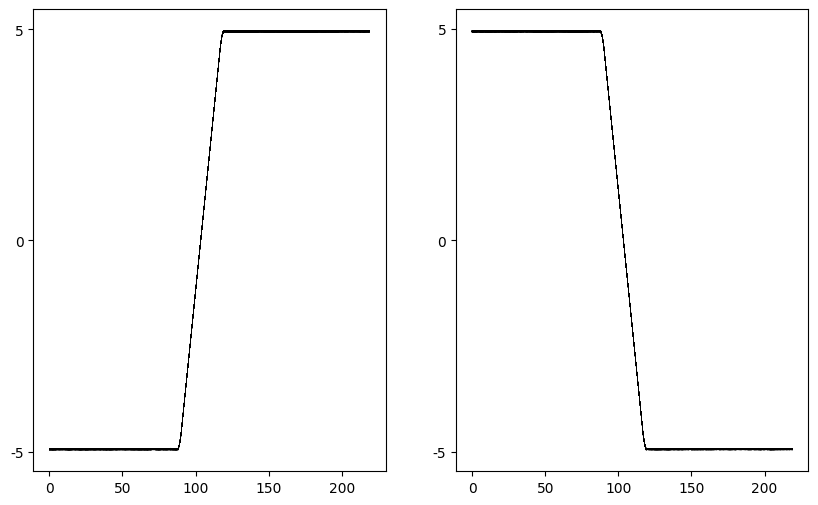

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
xFn = normWaveform(x_control,3)
[ax[1].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[0::2]]
[ax[0].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[1::2]];

ax[0].set_yticks([0,0.5,1])
ax[0].set_yticklabels([-5,0,5]);

ax[1].set_yticks([0,0.5,1])
ax[1].set_yticklabels([-5,0,5]);


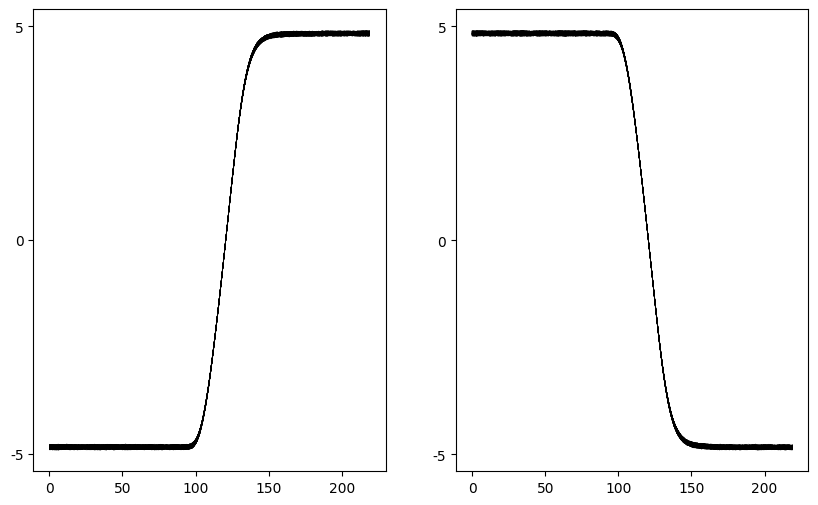

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
xFn = normWaveform(x_feedback,3)
[ax[1].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[0::2]]
[ax[0].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[1::2]];

ax[0].set_yticks([0,0.5,1])
ax[0].set_yticklabels([-5,0,5]);

ax[1].set_yticks([0,0.5,1])
ax[1].set_yticklabels([-5,0,5]);

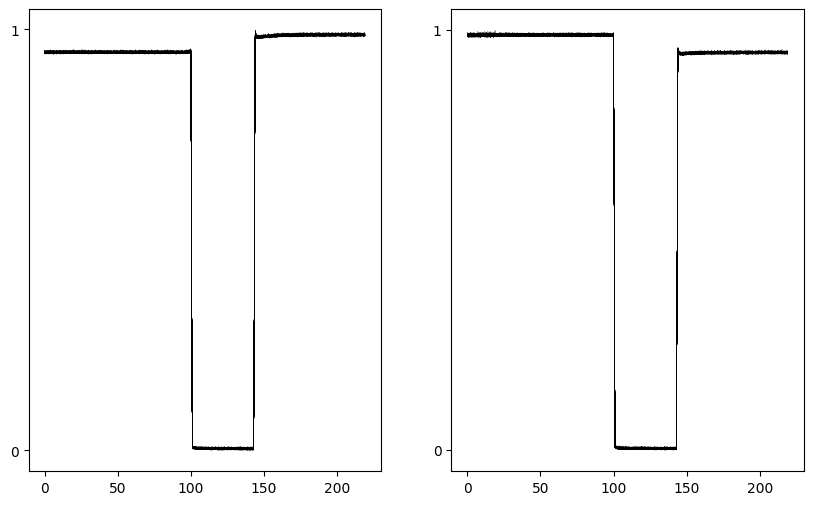

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
xFn = normWaveform(photodiode,1)
[ax[1].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[0::2]]
[ax[0].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[1::2]];

ax[0].set_yticks([0,1])
ax[0].set_yticklabels([0,1]);

ax[1].set_yticks([0,1])
ax[1].set_yticklabels([0,1]);

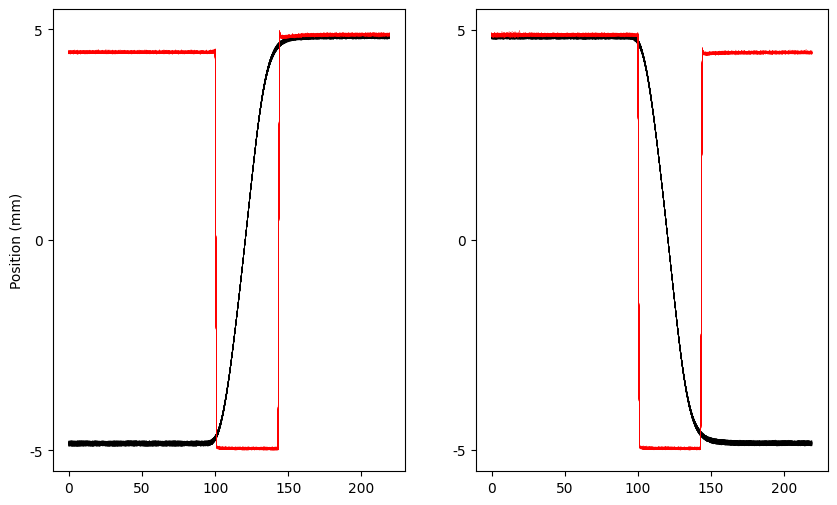

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
xFn = normWaveform(x_feedback,3)
[ax[1].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[0::2]]
[ax[0].plot(xFn[tF-100:tF+120],'-k',linewidth=0.25) for tF in f[1::2]];

xFp = normWaveform(photodiode,1)
[ax[1].plot(xFp[tF-100:tF+120],'-r',linewidth=0.25) for tF in f[0::2]]
[ax[0].plot(xFp[tF-100:tF+120],'-r',linewidth=0.25) for tF in f[1::2]];


ax[0].set_yticks([0,0.5,1])
ax[0].set_yticklabels([-5,0,5]);
ax[0].set_ylabel('Position (mm)');

ax[1].set_yticks([0,0.5,1])
ax[1].set_yticklabels([-5,0,5]);